In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [2]:
iris = load_iris()
X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df['Species'] = pd.Series(y).map(dict(enumerate(iris.target_names)))

print("Original Dataset Shape:", X.shape)
print("\nUnique Species:")
print(df['Species'].unique())

Original Dataset Shape: (150, 4)

Unique Species:
[np.str_('setosa') np.str_('versicolor') np.str_('virginica')]


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

print("\nReduced Dataset Shape:", X_lda.shape)


Reduced Dataset Shape: (150, 2)


In [7]:
lda_df = pd.DataFrame(
    X_lda,
    columns=['LD1', 'LD2']
)

lda_df['Species'] = df['Species']

print("\nDataset After LDA (First 5 Rows):")
print(lda_df.head())

print("\nExplained Variance Ratio:")
print(lda.explained_variance_ratio_)


Dataset After LDA (First 5 Rows):
        LD1       LD2 Species
0  8.061800 -0.300421  setosa
1  7.128688  0.786660  setosa
2  7.489828  0.265384  setosa
3  6.813201  0.670631  setosa
4  8.132309 -0.514463  setosa

Explained Variance Ratio:
[0.9912126 0.0087874]


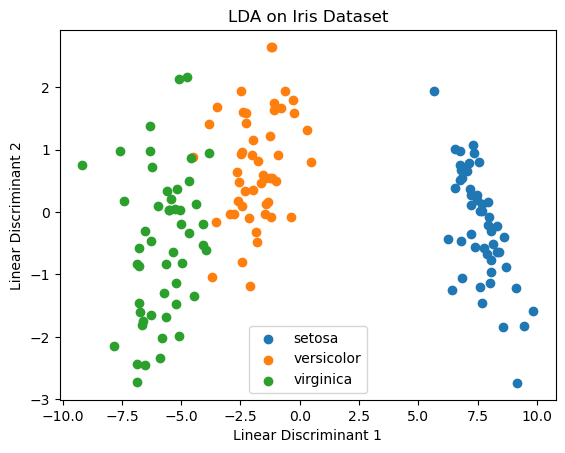

In [6]:
plt.figure()

for species in lda_df['Species'].unique():
    plt.scatter(
        lda_df[lda_df['Species'] == species]['LD1'],
        lda_df[lda_df['Species'] == species]['LD2'],
        label=species
    )

plt.xlabel('Linear Discriminant 1')
plt.ylabel('Linear Discriminant 2')
plt.title('LDA on Iris Dataset')

plt.legend()
plt.show()